In [1]:
# Import functions from preprocessing.py
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))

In [2]:
# Import functions from generation.py
from generation import generate_data, partition_domain_into_regions

In [3]:
B = 9  # Number of regions
n_i = 500  # Number of locations per region

# Generate data
y, x, w, e, s, region_assignments = generate_data(B, n_i, sigmasq = 5, length_scale=1.0, nu=0.5, seed=42, beta_true=2, tau_true=1)

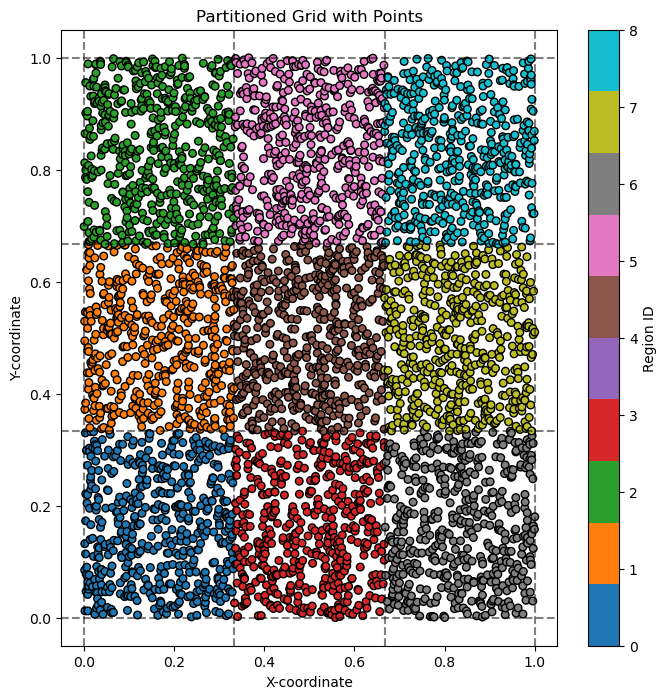

In [4]:
# Plot the grid and points
grid_size = int(np.ceil(np.sqrt(B)))

# Create the plot
plt.figure(figsize=(8, 8))

# Plot the grid
x_divisions = np.linspace(0, 1, grid_size + 1)
y_divisions = np.linspace(0, 1, grid_size + 1)
for xx in x_divisions:
    plt.axvline(x=xx, color='k', linestyle='--', alpha=0.5)
for yy in y_divisions:
    plt.axhline(y=yy, color='k', linestyle='--', alpha=0.5)

# Plot the points
plt.scatter(s[:, 0], s[:, 1], c=region_assignments, cmap='tab10', marker='o', edgecolor='k', s=30)

# Title and labels
plt.title("Partitioned Grid with Points")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.colorbar(label='Region ID')

plt.show()

In [5]:
y.shape, x.shape, s.shape, region_assignments.shape, w.shape, e.shape

((4500,), (4500, 1), (4500, 2), (4500,), (4500,), (4500,))

In [6]:
import numpy as np
from scipy.optimize import minimize
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import cdist

# Function to compute the NNGP covariance matrix using locations s
def compute_K_NN(s, K, num_neighbors):
    n = s.shape[0]
    K_NN = np.zeros_like(K)
    
    # Calculate pairwise distances between the locations s
    distances = cdist(s, s)
    
    for i in range(n):
        # Find the indices of the nearest neighbors based on location distances
        neighbor_indices = np.argsort(distances[i])[1:num_neighbors+1]
        K_NN[i, neighbor_indices] = K[i, neighbor_indices]
        K_NN[neighbor_indices, i] = K[neighbor_indices, i]
        
    return K_NN

def nngp_log_likelihood(y, s, X, beta, K, tau, num_neighbors):
    n = len(y)
    K_NN = K # Use location s here
    K_NN_noise = K_NN + tau**2 * np.eye(n)
    
    try:
        L = np.linalg.cholesky(K_NN_noise)
        log_det = 2 * np.sum(np.log(np.diagonal(L)))
    except np.linalg.LinAlgError:
        return -np.inf
    
    residual = y - X @ beta
    solve_term = np.linalg.solve(L.T, np.linalg.solve(L, residual))
    quadratic_term = residual.T @ solve_term
    
    log_likelihood = -0.5 * (n * np.log(2 * np.pi) + log_det + quadratic_term)
    return log_likelihood

# Function to compute the NNGP log-likelihood for given nu, length_scale, tau, and beta
def nngp_log_likelihood_with_params(params, s, X, y, num_neighbors):
    # Extract parameters from the input
    nu = params[0]
    length_scale = params[1]
    tau = params[2]
    sigmasq= params[3]
    beta = params[4:]
    
    # Compute the full covariance matrix K using the skMatern kernel
    matern_kernel = sigmasq * Matern(length_scale=length_scale, nu=0.5)
    K = matern_kernel(s)  # Calculate the kernel matrix using location s
    
    # Compute the NNGP log-likelihood
    return -nngp_log_likelihood(y, s, X, beta, K, tau, num_neighbors)  # Negative for minimization


# Initial guess for parameters: [nu, length_scale, tau, beta_1, ..., beta_p]
params_init = np.array([0.5,0.3, 0.3, 2] + list(np.zeros(1)))
num_neighbors= 3

bounds = [(0.1, 10.0), (0.1, 10.0), (0.1, 10.0), (0.1, 10.0)] + [(None, None)] * (params_init.shape[0] - 4)

# Optimization with bounds
result = minimize(
    nngp_log_likelihood_with_params,
    params_init,
    args=(s, x, y, num_neighbors),
    method='L-BFGS-B',bounds=bounds
)

# Output the optimized parameters
print("Optimized Parameters:")
print("nu:", result.x[0])
print("length_scale:", result.x[1])
print("sigmasq/length_scale:", result.x[3]/result.x[1])
print("tau:", result.x[2])
print("sigmasq:", result.x[3])
print("beta:", result.x[4:])
print("Log-Likelihood:", -result.fun)


KeyboardInterrupt: 

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import cdist
import numpy as np
import gpytorch
import torch
import torch.special

# PyTorch Module for optimizing NNGP parameters
class NNGPModel(nn.Module):
    def __init__(self, input_dim, device='cpu'):
        super(NNGPModel, self).__init__()
        self.device = device

        # Learnable parameters
        self.nu = nn.Parameter(torch.tensor(0.5, device=device))
        self.length_scale = nn.Parameter(torch.tensor(1.5, device=device))
        self.tau = nn.Parameter(torch.tensor(1.0, device=device))
        self.sigmasq = nn.Parameter(torch.tensor(2.0, device=device))
        self.beta = nn.Parameter(torch.zeros(input_dim, device=device))
    
    def nngp_log_likelihood(self, y, s, X, beta, K):
        n = y.shape[0]
        K_NN = K  # Use precomputed covariance
        K_NN_noise = K_NN + (self.tau**2) * torch.eye(n, device=s.device)
        log_det = torch.logdet(K_NN_noise)
        
        residual = y - X @ beta
        quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
        log_likelihood = -0.5 * (log_det + quadratic_term)
        return log_likelihood   
        

    def forward(self, s, X, y):
        # Compute covariance matrix using Matern kernel
        scaled_s = s / self.length_scale
        matern_kernel = gpytorch.kernels.MaternKernel(nu= 0.5)
        K = self.sigmasq * matern_kernel(scaled_s)
        return -self.nngp_log_likelihood(y, s, X, self.beta, K)

# Sample Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1
# num_neighbors= 3

y = torch.tensor(y, dtype=torch.float32, device=device)
x = torch.tensor(x, dtype=torch.float32, device=device)
w = torch.tensor(w, dtype=torch.float32, device=device)
e = torch.tensor(e, dtype=torch.float32, device=device)
s = torch.tensor(s, dtype=torch.float32, device=device)
region_assignments = torch.tensor(region_assignments, dtype=torch.int64, device=device)  # Region indices as integers


# Initialize and optimize the model
model = NNGPModel(input_dim, device).to(device)
# optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(1000)):
    optimizer.zero_grad()
    loss = model(s, x, y)
    loss.backward()
    optimizer.step()
    
    # with torch.no_grad():
    #     model.length_scale.clamp_(min = .0001)
    #     model.tau.clamp_(min = .0001)
    #     model.sigmasq.clamp_(min = .0001)
    #     model.nu.clamp_(min = .0001)
        
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")
        print("nu:", model.nu.item())
        print("length_scale:", model.length_scale.item())
        print("sigma_sq/length_scale:", model.sigmasq.item()/np.sqrt(model.length_scale.item()))
        print("tau:", model.tau.item())
        print("sigmasq:", model.sigmasq.item())
        print("beta:", model.beta.detach().cpu().numpy())
        print("=="*20)

# # Optimization step
# def closure():
#     optimizer.zero_grad()
#     loss = model(s, x, y, num_neighbors)
#     loss.backward()
#     return loss

# optimizer.step(closure)
# with torch.no_grad():
#     print("Optimized Parameters:")
#     print("nu:", model.nu.item())
#     print("length_scale:", model.length_scale.item())
#     print("tau:", model.tau.item())
#     print("sigmasq:", model.sigmasq.item())
    

# # Output the optimized parameters
# print("Optimized Parameters:")
# print("nu:", model.nu.item())
# print("length_scale:", model.length_scale.item())
# print("tau:", model.tau.item())
# print("sigmasq:", model.sigmasq.item())
# print("beta:", model.beta.detach().cpu().numpy())

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/gy/14_v6tv14gz17t09_6vmdr4c0000gn/T/ipykernel_62152/1911532339.py:31: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_f21i7zqrcp/croot/pytorch-select_1725478817058/work/aten/src/ATen/native/TensorShape.cpp:3679.)
  quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
  0%|          | 1/1000 [00:00<15:13,  1.09it/s]

Iteration 0, Loss: 3115.25634765625
nu: 0.5
length_scale: 1.4898500442504883
sigma_sq/length_scale: 1.6465751377912459
tau: 1.0098999738693237
sigmasq: 2.0097999572753906
beta: [0.01]


 10%|█         | 101/1000 [01:40<12:19,  1.22it/s]

Iteration 100, Loss: 2596.535888671875
nu: 0.5
length_scale: 0.39873212575912476
sigma_sq/length_scale: 4.49473519368547
tau: 0.8958593606948853
sigmasq: 2.8382112979888916
beta: [0.9369784]


 20%|██        | 201/1000 [02:58<10:15,  1.30it/s]

...

 80%|████████  | 801/1000 [10:52<02:36,  1.28it/s]

Iteration 800, Loss: 2965.4345703125
nu: 0.5
length_scale: 0.05389777943491936
sigma_sq/length_scale: 17.710706617425185
tau: 0.055027686059474945
sigmasq: 4.111699104309082
beta: [2.0086687]


 90%|█████████ | 901/1000 [12:09<01:15,  1.31it/s]

Iteration 900, Loss: 2893.486328125
nu: 0.5
length_scale: 0.05864202231168747
sigma_sq/length_scale: 17.777858460446627
tau: 0.000546621042303741
sigmasq: 4.3051066398620605
beta: [2.014666]


100%|██████████| 1000/1000 [13:27<00:00,  1.24it/s]


In [6]:
y.shape, x.shape, w.shape, e.shape, s.shape, region_assignments.shape

((900,), (900, 1), (900,), (900,), (900, 2), (900,))

In [ ]:
import numpy as np
from scipy.optimize import minimize

def optimize_nngp_log_likelihood(y, s_i, num_neighbors, init_params):
    """
    Optimizes the NNGP log-likelihood by tuning Matérn kernel parameters.

    Parameters:
        y : np.array (n,)
            Observed outcomes (response variable).
        s_i : np.array (n, d)
            Locations where observations are taken (n points in d dimensions).
        num_neighbors : int
            Number of nearest neighbors to consider for NNGP approximation.
        init_params : tuple
            Initial guess for (nu, length_scale, tau²).

    Returns:
        opt_result : OptimizeResult
            SciPy optimization result containing optimized parameters.
    """
    def negative_log_likelihood(params):
        nu, length_scale, tau2 = params
        return -nngp_log_likelihood(y, s_i, nu, length_scale, num_neighbors, tau2)

    # Set bounds for the parameters (to ensure positive values)
    bounds = [(0.1, 10),  # nu (smoothness)
              (0.01, 10),  # length_scale
              (1e-2, 1e2)]   # tau² (error variance)

    # Run optimization
    opt_result = minimize(negative_log_likelihood, init_params, bounds=bounds, method='L-BFGS-B')

    return opt_result

In [11]:
optimize_nngp_log_likelihood(y, s, 5, (1.5, 1.0, 0.1))  # Example usage

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 1550.0175901769812
        x: [ 1.806e-01  1.333e+00  1.000e+00]
      nit: 22
      jac: [ 6.958e-03  2.274e-04 -5.979e+01]
     nfev: 108
     njev: 27
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [9]:
nngp_log_likelihood(y, s_i=s, nu=0.5, length_scale=3, num_neighbors=5, tau2=0.1)

-5694.485975978226

In [ ]:
# import rpy2.robjects as robjects

# # Define an R function
# r_code = """
# square <- function(x) {
#   return(x^2)
# }
# """

# # Load R function into Python
# robjects.r(r_code)

# # Call the R function
# square = robjects.r['square']
# result = square(5)
# print(result)  # Output: [1] 25

During startup - Warning messages:
1: Setting LC_COLLATE failed, using "C" 
2: Setting LC_TIME failed, using "C" 
3: Setting LC_MESSAGES failed, using "C" 
4: Setting LC_MONETARY failed, using "C" 


[1] 25



In [24]:
pip install gpytorch

Note: you may need to restart the kernel to use updated packages.
